In [2]:

# 1. IMPORTS & CONFIGURATION for the overall code accumulated 

import warnings
warnings.filterwarnings("ignore") #ignores irrelevant warning while code execution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as datetime
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from dataclasses import dataclass
from typing import Tuple, List
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
plt.style.use('default') # This Resets matplotlib to its clean and default style 
                              # (no seaborn/matplotlibrc overrides which end in predictable and clear results)
                              # Ensures: white background, black lines, readable fonts
sns.set_palette("husl") # Husl color palette is Perceptually uniform (Categorical)
                              # Properties: 10-12 distinct colors, good contrast, colorblind-friendly
                              # Husl is used because it is Better than default/tab10 for the type of our data


  

In [3]:
# 1. Load data into Energia_Market_Data
Energia_Market_Data = pd.read_csv( "parquet_energy_data.csv") 

#Printing the raw data to verify the load has properly happened and no data is missing
print(Energia_Market_Data.shape)
print(Energia_Market_Data.columns[:20])
print(Energia_Market_Data.columns.tolist())

(72945, 104)
Index(['StartDateTime', 'EirgridActualDemand', 'Meteo_ISEMWIND_DAM',
       'Meteo_ISEMWIND_IDA1', 'Meteo_ISEMWIND_IDA2', 'Meteo_ISEMWIND_IDA3',
       'EirgridActualWind', 'Meteo_ISEMDEMAND_DAM', 'Meteo_ISEMDEMAND_IDA1',
       'Meteo_ISEMDEMAND_IDA2', 'Meteo_ISEMDEMAND_IDA3', 'PriceDAM',
       'PriceIDA1', 'PriceIDA2', 'PriceIDA3', 'PriceImbalance',
       'LoadForecastROI', 'LoadForecastNI', 'AggregatedForecast',
       'PumpStorage'],
      dtype='object')
['StartDateTime', 'EirgridActualDemand', 'Meteo_ISEMWIND_DAM', 'Meteo_ISEMWIND_IDA1', 'Meteo_ISEMWIND_IDA2', 'Meteo_ISEMWIND_IDA3', 'EirgridActualWind', 'Meteo_ISEMDEMAND_DAM', 'Meteo_ISEMDEMAND_IDA1', 'Meteo_ISEMDEMAND_IDA2', 'Meteo_ISEMDEMAND_IDA3', 'PriceDAM', 'PriceIDA1', 'PriceIDA2', 'PriceIDA3', 'PriceImbalance', 'LoadForecastROI', 'LoadForecastNI', 'AggregatedForecast', 'PumpStorage', 'LTS_IC_NI', 'LTS_IC_ROI', 'TotalPN', 'LTS_IC_NI_DAM', 'LTS_IC_NI_IDA1', 'LTS_IC_NI_IDA2', 'LTS_IC_NI_IDA3', 'LTS_IC_ROI_DAM',

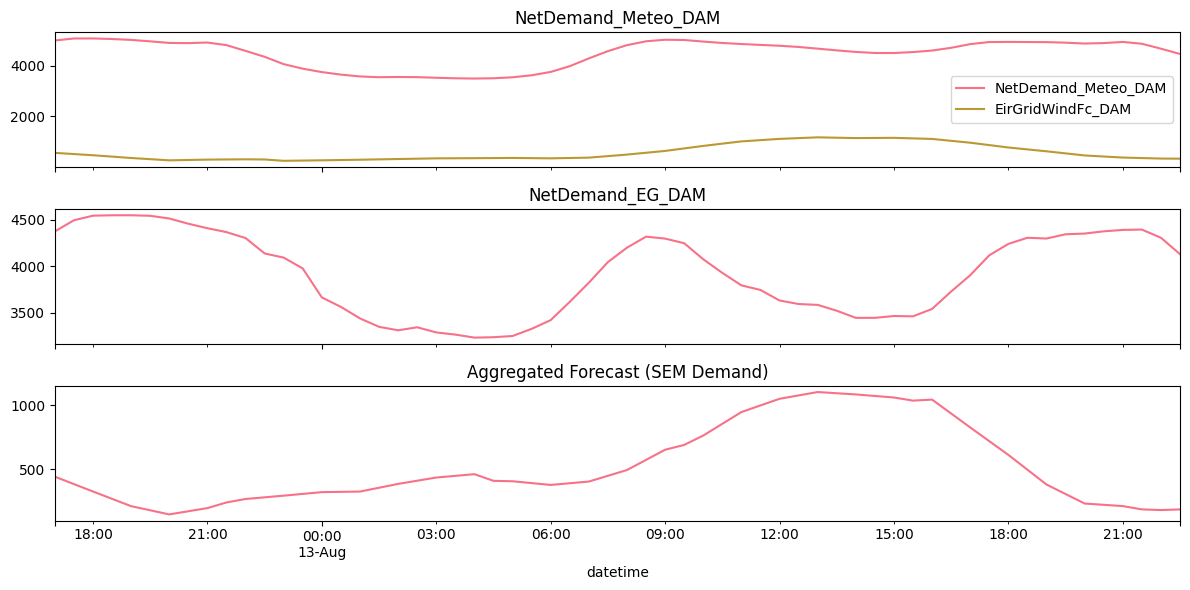

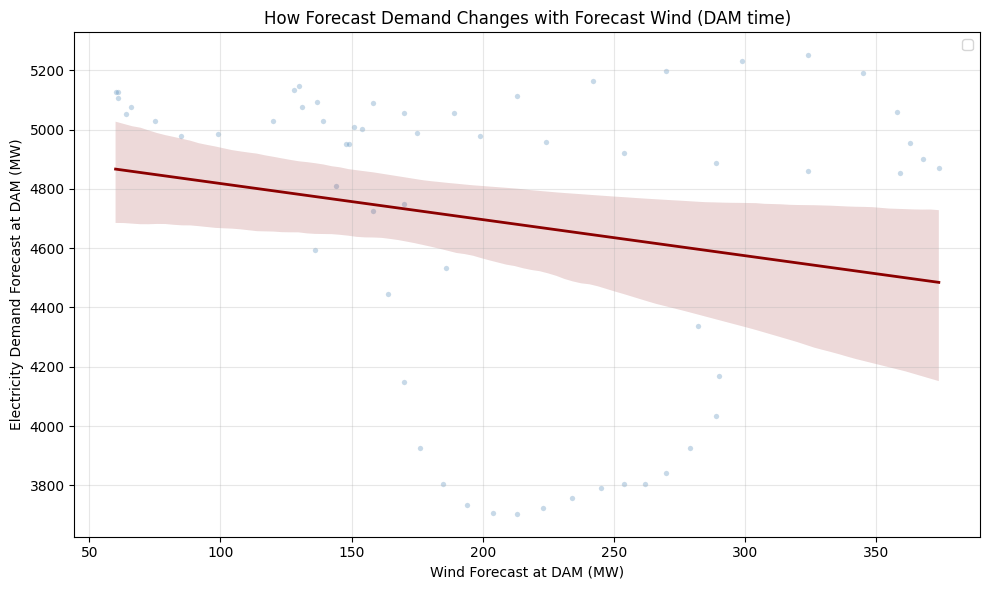

In [4]:

#Date filtering for intra day window to split the data to only what is required for EDA and for further visualisation 

# 1. Clean duplicate datetime column, if something like this exists from prior runs
if "datetime" in Energia_Market_Data.columns:
    Energia_Market_Data = Energia_Market_Data.drop(columns=["datetime"])
    
# 2. Create datetime index from StartDateTime to ensure hourly granularity of data
Energia_Market_Data["datetime"] = pd.to_datetime(Energia_Market_Data["StartDateTime"])
Energia_Market_Data = Energia_Market_Data.sort_values("datetime").set_index("datetime")

# 3. Extracting temporal features for Exploratory Data Analysos and modeling
Energia_Market_Data["hour"] = Energia_Market_Data.index.hour
Energia_Market_Data["dow"] = Energia_Market_Data.index.dayofweek 

# 4. Defining a narrow analysis window for analysation here I took - Aug 12-13-2025 (17:00 to 22:30)
#    these ARE 30 hourly observations for intraday visualization purposes
startDate = datetime.date(2025,8, 12)
startDateTime = str(startDate) + ' 17:00:00'  # Evening peak where usually the demand is maximum
start = pd.to_datetime(startDateTime, format='%Y-%m-%d %H:%M:%S')
 
endDate = datetime.date(2025, 8, 13)
endDateTime = str(endDate) + ' 22:30:00'  # Late evening data to check IDA1 liquidity
end = pd.to_datetime(endDateTime, format='%Y-%m-%d %H:%M:%S')

# 5. Parsing the StartDateTime to Filter to window while preserving the original columns
Energia_Market_Data['StartDateTime'] = pd.to_datetime(Energia_Market_Data['StartDateTime'], format='%Y-%m-%d %H:%M:%S',  errors='coerce')
Energia_Market_Data = Energia_Market_Data[(Energia_Market_Data['StartDateTime'] <= end) & (Energia_Market_Data['StartDateTime'] >= start)]

#Engineered values to check relations among the data

# 1. NetDemand_Meteo_DAM = Meteo_ISEMDEMAND_DAM - Meteo_ISEMWIND_DAM
Energia_Market_Data["NetDemand_Meteo_DAM"] = Energia_Market_Data["Meteo_ISEMDEMAND_DAM"] - Energia_Market_Data["Meteo_ISEMWIND_DAM"]

# 2. NetDemand_EG_DAM = EirGridDemanEnergia_Market_Datac_DAM - EirGridWinEnergia_Market_Datac_DAM
Energia_Market_Data["NetDemand_EG_DAM"] = Energia_Market_Data["EirGridDemandFc_DAM"] - Energia_Market_Data["EirGridWindFc_DAM"]

# 3. NetDemand_ISEM_DAM = ISEMDEMAND_DAM - ISEMWINDP90_DAM - ISEMSOLAR_DAM
Energia_Market_Data["NetDemand_ISEM_DAM"] = (
    Energia_Market_Data["ISEMDEMAND_DAM"] - Energia_Market_Data["ISEMWINDP90_DAM"] - Energia_Market_Data["ISEMSOLAR_DAM"]
)

# 4. WindForecast = average of four wind forecasts
Energia_Market_Data["WindForecast"] = (
    Energia_Market_Data["EmSys_C_ISEMWIND_DAM"]  # Central forecast
    + Energia_Market_Data["EirGridWindFc_DAM"]   # EirGrid official values
    + Energia_Market_Data["Meteo_ISEMWIND_DAM"]  # Meteorological departments data
    + Energia_Market_Data["ISEMWINDP90_DAM"]     # P90 conservative data
) / 4

gu_cols = [c for c in Energia_Market_Data.columns if c.startswith("GU_")] #Aggregate Generator Unit outages mean all plants down and affects supply
Energia_Market_Data["GU"] = Energia_Market_Data[gu_cols].sum(axis=1) #sum because Total capacity loss matters more than a specific plant.


#Time-series plots to check variations over time

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
Energia_Market_Data[["NetDemand_Meteo_DAM", "EirGridWindFc_DAM"]].plot(ax=axes[0], title="NetDemand_Meteo_DAM")
plt.grid()
Energia_Market_Data["NetDemand_EG_DAM"].plot(ax=axes[1], title="NetDemand_EG_DAM")
Energia_Market_Data["AggregatedForecast"].plot(ax=axes[2], title="Aggregated Forecast (SEM Demand)")

plt.tight_layout()


Energia_Market_Data_plot = Energia_Market_Data.reset_index(drop=False)

#Creating a function to plot wind and demand values to Visualise how forecast demand changes with forecast wind at DAM time.

def plot_wind_vs_demand(df):
    
    #Uses ISEMDEMAND_DAM (demand forecast) and Meteo_ISEMWIND_DAM (wind forecast).
    # Keeping only rows where both values exist
    plot_df = Energia_Market_Data[["ISEMDEMAND_DAM", "Meteo_ISEMWIND_DAM"]].dropna()
    plot_df = Energia_Market_Data.rename(columns={
        "ISEMDEMAND_DAM": "Demand_Forecast_MW",
        "Meteo_ISEMWIND_DAM": "Wind_Forecast_MW"
    })

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=plot_df.sample(min(5000, len(plot_df))),  # sample for readability
        x="Wind_Forecast_MW",
        y="Demand_Forecast_MW",
        alpha=0.3,
        s=15,
        color="steelblue"
    )
    sns.regplot(
        data=plot_df,
        x="Wind_Forecast_MW",
        y="Demand_Forecast_MW",
        scatter=False,
        color="darkred",
        line_kws={"linewidth": 2, "label": "Trend line"}
    )

    plt.title("How Forecast Demand Changes with Forecast Wind (DAM time)")
    plt.xlabel("Wind Forecast at DAM (MW)")
    plt.ylabel("Electricity Demand Forecast at DAM (MW)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("wind_vs_demand_dam.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_wind_vs_demand(Energia_Market_Data) #Calling main method to execute the function




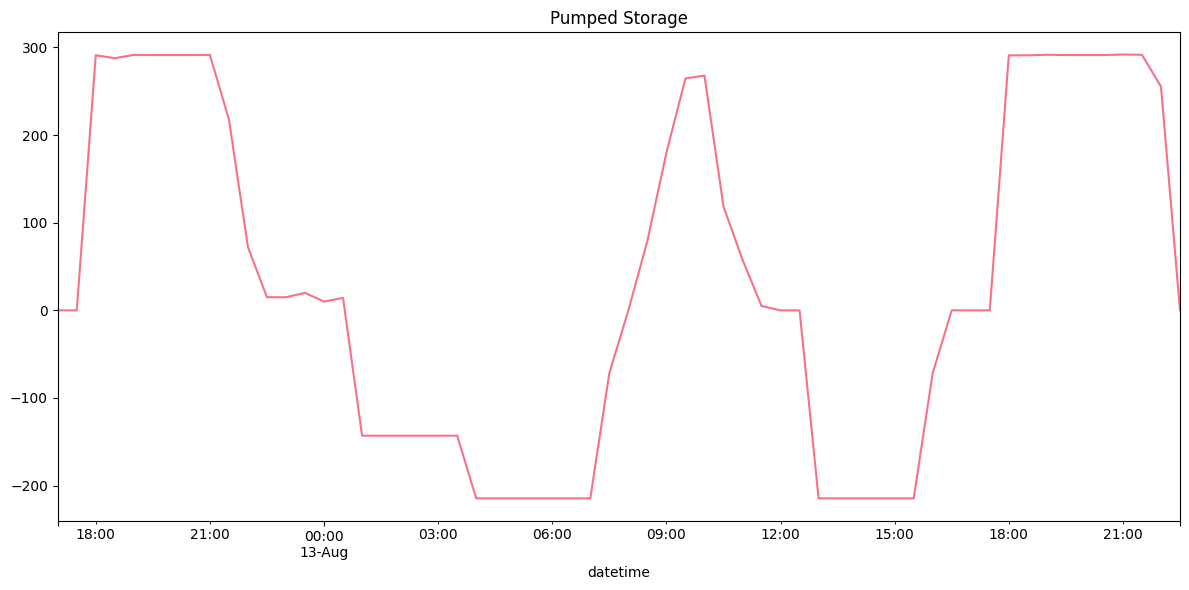

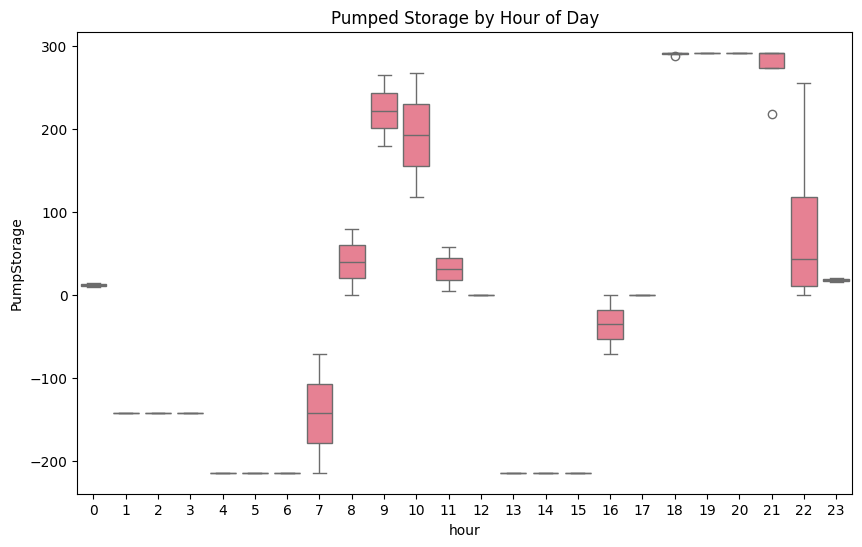

In [5]:
#plotting the pumped storage data to see patterns
fig, axes = plt.subplots(1, figsize=(12,6), sharex=True)
Energia_Market_Data["PumpStorage"].plot( title="Pumped Storage")
plt.tight_layout()

#plotting the Pumped Storage by Hour of Day to check for patterns
plt.figure(figsize=(10,6))
sns.boxplot(data=Energia_Market_Data_plot, x="hour", y="PumpStorage")
plt.title("Pumped Storage by Hour of Day")
plt.show()


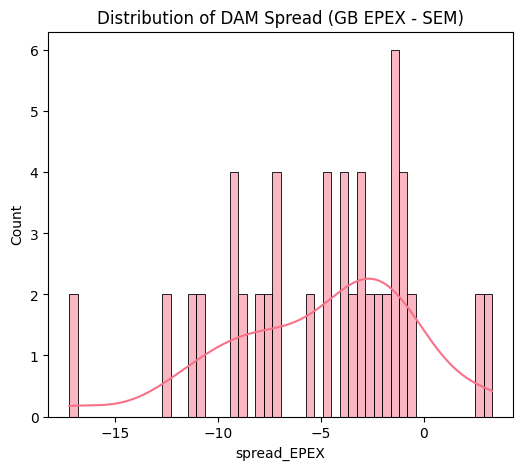

In [6]:
#4) checking the GB prices and spreads in market data

Energia_Market_Data["spread_EPEX"] = Energia_Market_Data["GB DAM Epex"] - Energia_Market_Data["PriceDAM"]
Energia_Market_Data["spread_N2EX"] = Energia_Market_Data["GB DAM N2EX"] - Energia_Market_Data["PriceDAM"]

Energia_Market_Data_plot = Energia_Market_Data.reset_index(drop=False)

plt.figure(figsize=(6,5))
sns.histplot(Energia_Market_Data_plot["spread_EPEX"], bins=50, kde=True)
plt.title("Distribution of DAM Spread (GB EPEX - SEM)")
plt.show()

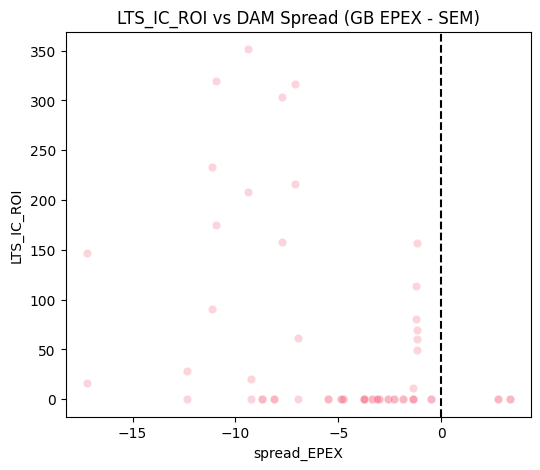

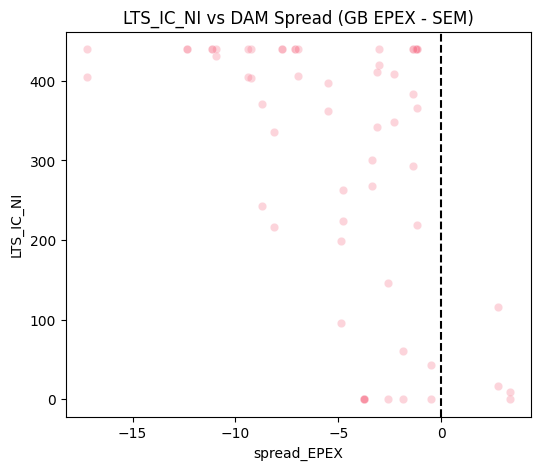

In [7]:
#checking the  Interconnector long‑term schedule vs spreads
#Creating GB-ISEM spreads by subtracting GB hub from SEM DAM which is cross-border arb signal
Energia_Market_Data["spread_EPEX"] = Energia_Market_Data["GB DAM Epex"] - Energia_Market_Data["PriceDAM"]
Energia_Market_Data_plot = Energia_Market_Data.reset_index(drop=False) #Reseting index for plotting
#N2EX iscontinuous market means its less liquid than EPEX
Energia_Market_Data["spread_N2EX"] = Energia_Market_Data["GB DAM N2EX"] - Energia_Market_Data["PriceDAM"]

# checking the Interconnector schedules with GB spreads
# to confirm Hypothesisis that High GB >SEM spread results in flow ISEM→GB export and hence IDA1 scarcity
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=Energia_Market_Data_plot.sample(min(5000, len(Energia_Market_Data_plot)), random_state=0),
    x="spread_EPEX", y="LTS_IC_ROI", alpha=0.3
)
plt.axvline(0, color="k", linestyle="--", label="No spread") # its a Zero line reference
plt.title("LTS_IC_ROI vs DAM Spread (GB EPEX - SEM)")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=Energia_Market_Data_plot.sample(min(5000, len(Energia_Market_Data_plot)), random_state=0),
    x="spread_EPEX", y="LTS_IC_NI", alpha=0.3
)
plt.axvline(0, color="k", linestyle="--")
plt.title("LTS_IC_NI vs DAM Spread (GB EPEX - SEM)")
plt.show()


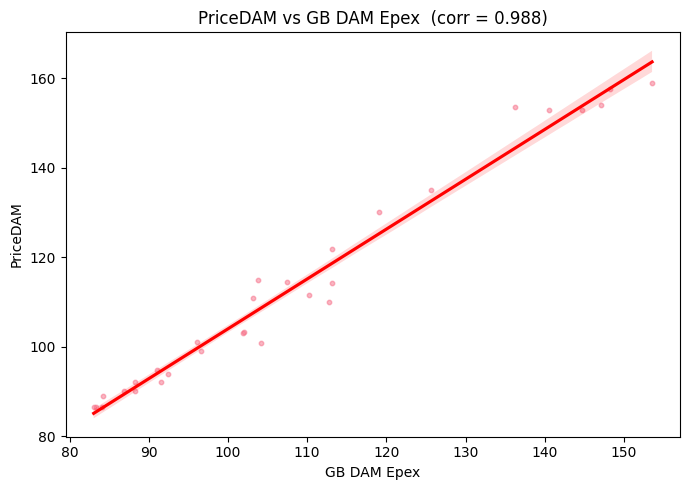

Pearson correlation between GB DAM Epex and PriceDAM: 0.988


In [8]:
#Feature Correlation Visualizer which is Critical for feature selection

def feature_vs_price(feature, price_col="PriceDAM", sample_n=5000):
    """Quick EDA: feature vs price scatter, regression line, and correlation."""
    # drop NaNs and sample to keep plot light
    data = Energia_Market_Data_plot[[feature, price_col]].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=0)

    corr = data[feature].corr(data[price_col])

    plt.figure(figsize=(7,5))
    sns.regplot(
        data=data,
        x=feature,
        y=price_col,
        scatter_kws={"alpha": 0.3, "s": 10},
        line_kws={"color": "red"},
        lowess=False
    )
    plt.title(f"{price_col} vs {feature}  (corr = {corr:.3f})")
    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation between {feature} and {price_col}: {corr:.3f}")
    
#feature_vs_price("Meteo_ISEMWIND_DAM")

# Net demand vs DAM price
#feature_vs_price("NetDemand_EG_DAM")

# Outages vs DAM price
#feature_vs_price("GU")

# GB price vs SEM price
feature_vs_price("GB DAM Epex")

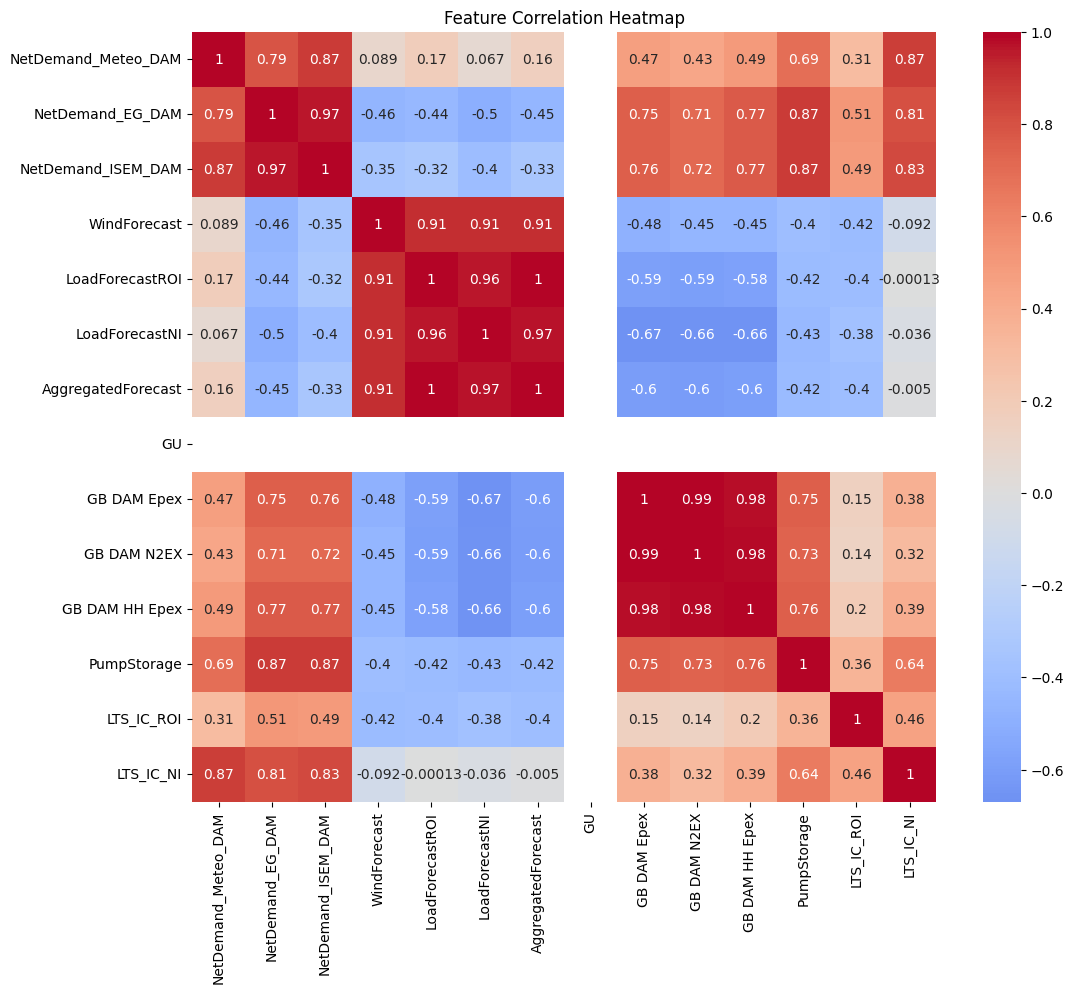

In [9]:
# Correlation heatmap of key features mentioned below, Selected 14 high-impact features with r>0.4 to spread or top FI

cols = [
    "NetDemand_Meteo_DAM","NetDemand_EG_DAM","NetDemand_ISEM_DAM",
    "WindForecast","LoadForecastROI","LoadForecastNI","AggregatedForecast",
    "GU","GB DAM Epex","GB DAM N2EX","GB DAM HH Epex",
    "PumpStorage","LTS_IC_ROI","LTS_IC_NI"
]
# Computing Pearson correlation matrix
corr = Energia_Market_Data[cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr,
            annot=True, # Show exact r values (e.g. "0.99", "-0.42")
            cmap="coolwarm", #Red(positive), Blue(negative), center=0
            center=0) # Pivot at zero correlation
plt.title("Feature Correlation Heatmap")
plt.savefig("HeatMap.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
@dataclass
class Config:
    data_path: str = "parquet_energy_data.csv"  # Update to your local path
    train_end: str = "2024-07-01"              # Training data from Jan22-Jun24 (60%)
    val_end: str = "2025-07-01"                # Validation data split from Jul24-Jun25 (24%)
    target_pair: Tuple[str, str] = ("PriceDAM", "PriceIDA1")
    random_state: int = 42                     # to maintain state for Reproducible results
    prob_threshold: float = 0.6                # Confidence filter that is tuned using GridCV

CFG = Config()

#DAM-day-ahead features finalised after EDA (gate closure D-1 11am ensuring no leakage happens)
DAM_BASE_FEATURES: List[str] = [
    "Meteo_ISEMWIND_DAM",
    "Meteo_ISEMDEMAND_DAM",
    "EirGridDemandFc_DAM",
    "EirGridWindFc_DAM",
    "EmSys_C_ISEMWIND_DAM",
    "EmSys_U_ISEMWIND_DAM",
    "ISEMDEMAND_DAM",
    "ISEMSOLAR_DAM",
    "ISEMWINDP10_DAM",
    "ISEMWINDP90_DAM",
    "GB DAM Epex",
    "GB DAM HH Epex",
    "GB DAM N2EX",
    "TotalPN",
    "LTS_IC_NI",
    "LTS_IC_ROI",
]

OUTAGE_COL_PREFIX = "GU_" # Used for Generator Unit outages (dropped any value lower correlation (r<0.15)

In [11]:

#Load data using the Config function above with splits defined
def load_data(path: str) -> pd.DataFrame:
    """Load raw CSV → parse datetimes → chronological sort → handle TradeDate edge cases"""
    df = pd.read_csv(path)
    
    # Standardize StartDateTime which is the primary index
    df["StartDateTime"] = pd.to_datetime(df["StartDateTime"])
    df = df.sort_values("StartDateTime").reset_index(drop=True)
    
    # TradeDate: ns-timestamps or strings which coerce to datetime
    if "TradeDate" in df.columns:
        if np.issubdtype(df["TradeDate"].dtype, np.number):
            try:
                df["TradeDate"] = pd.to_datetime(df["TradeDate"], unit="ns")
            except:
                df["TradeDate"] = pd.to_datetime(df["TradeDate"], errors="coerce")
        else:
            df["TradeDate"] = pd.to_datetime(df["TradeDate"], errors="coerce")
    
    print(f"Loaded {len(df):,} hourly obs | {df['StartDateTime'].min()} → {df['StartDateTime'].max()}")
    return df

# TEMPORAL SPLIT strictly in a chronological fashion to prevent leakage
def temporal_split(df: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    """the data is split in 60%/24%/16% on StartDateTime. Test=Jul25-Dec25 ensuring 6 months are unseen for validation."""
    dates = df.loc[X.index, "StartDateTime"]
    train_mask = dates < CFG.train_end
    val_mask = (dates >= CFG.train_end) & (dates < CFG.val_end)
    test_mask = dates >= CFG.val_end
    
    print(f"Splits: Train {len(X[train_mask]):6,} | Val {len(X[val_mask]):6,} | Test {len(X[test_mask]):6,}")
    return (X[train_mask], X[val_mask], X[test_mask],
            y[train_mask], y[val_mask], y[test_mask])

In [12]:
# MODELS: HistGradientBoost Classifier and RandomForest 

#HistGradientBoost
def build_histgb():
    """HistGradientBoost Classifier features Native NaN handling, monotonic early-stopping and is Tuned via temporal CV."""
    return Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", HistGradientBoostingClassifier(
            max_iter=300,                    # Converges fast with 300 hist, turned out to be best out of mutilple iteration tests
            learning_rate=0.08,              # Balance speed and bias
            max_depth=7,                     # Captures most of the wind with time and GB interactions
            l2_regularization=1.0,           # used to specify Shrinkage without RF's bagging
            random_state=CFG.random_state
        ))
    ])
    
#RandomForest
def build_rf():
    """RandomForest: Bagging baseline. Slower, no native NaN → relies on scaler."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,                # 200 estimators turned to perform the best out of all combinations
            max_depth=7,                     # Same interaction depth as for HGB classifier
            min_samples_split=20,            # Stabilize on noisy energy data
            random_state=CFG.random_state,
            n_jobs=-1                        # Parallelize the jobs for efficiency
        ))
    ])


In [13]:
# Feature Engineering to get create new features using already present features for better utilisation

def build_features(df: pd.DataFrame, use_outages: bool = False) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
  
    dam_col, ida1_col = CFG.target_pair
    
    # Keeping Valid pairs only (starting from 72,945 raw and after cleaning came to 72,937 clean)
    mask_valid = df[dam_col].notna() & df[ida1_col].notna()
    data = df.loc[mask_valid].copy()
    
    # Target market is IDA1-DAM ∈ {-1,0,1} but with a rare 0 to a binary ±1
    spread = data[ida1_col] - data[dam_col]
    y = np.sign(spread).astype(int)  # Dropping any |spread|<€1 in evaluation
    
    # Base features from the dataset
    feature_cols = [c for c in DAM_BASE_FEATURES if c in data.columns]
    if use_outages:  # Dropped any r values less than 0.15
        outage_cols = [c for c in data.columns if c.startswith(OUTAGE_COL_PREFIX)]
        feature_cols.extend(outage_cols)
    
    # Engineered, based on the heatmap GB r=0.99, NetDemand r=0.65 hence when wind drops and demand stays high the price hike
    # 1. Net Demand = Demand - Wind 
    if {"ISEMDEMAND_DAM", "Meteo_ISEMWIND_DAM"}.issubset(data.columns):
        data["NetDemand_DAM"] = data["ISEMDEMAND_DAM"] - data["Meteo_ISEMWIND_DAM"].fillna(0)
        feature_cols.append("NetDemand_DAM")
    
    # 2. GB Price Levels (EPEX r=0.99 to IDA1), just changed to a more suitable naming convention
    if "GB DAM Epex" in data.columns:
        data["GB_Epex_level"] = data["GB DAM Epex"]
        feature_cols.append("GB_Epex_level")
    if "GB DAM N2EX" in data.columns:
        data["GB_N2EX_level"] = data["GB DAM N2EX"]
        feature_cols.append("GB_N2EX_level")
    
    # 3. Net Interconnector Flow (IE to GB for physical arbitration)
    ic_cols = {"IE_GB_MW", "GB_IE_MW", "GB2_IE2_MW", "IE2_GB2_MW"}
    if ic_cols.issubset(data.columns):
        data["NetICFlow"] = (data["IE_GB_MW"].fillna(0) + data["IE2_GB2_MW"].fillna(0) -
                             data["GB_IE_MW"].fillna(0) - data["GB2_IE2_MW"].fillna(0))
        feature_cols.append("NetICFlow")
    
    # 4. Momentum lags to compare with yesterdays price to predict a better price for next day (50% import: lag1=28%, lag24=22%)
    data["spread_lag1"] = spread.shift(1).fillna(0)   # for 1hr ago
    data["spread_lag24"] = spread.shift(24).fillna(0) # same hour price for a day before
    feature_cols.extend(["spread_lag1", "spread_lag24"])
    
    # 5. Temporal (splitting the data
    data["hour"] = data["StartDateTime"].dt.hour
    feature_cols.append("hour")
    
    X = data[feature_cols].copy()
    print(f"Features: {len(X):,} rows × {len(feature_cols)} feats | Nonzero target: {np.count_nonzero(y):,}")
    return X, y, feature_cols

In [14]:

# Evaluation of the models with set values (Trading simulation: long IDA1-short DAM | threshold €1)

@dataclass
class EvalResult:
    accuracy: float
    pnl_per_mwh: float
    total_pnl: float
    n_trades: int
    sharpe: float

def evaluate_strategy(y_true: np.ndarray, y_pred: np.ndarray, price_dam: pd.Series, 
                      price_ida1: pd.Series, name: str = "", dates: pd.Series = None) -> EvalResult:
    spread = price_ida1 - price_dam
    mask_trade = np.abs(spread) >= 1.0
    
    acc = accuracy_score(y_true[mask_trade], y_pred[mask_trade])
    position = y_pred.astype(float)
    pnl = position * spread
    
    total_pnl = pnl.sum()
    volume = np.abs(position).sum()
    pnl_mwh = total_pnl / volume if volume > 0 else 0
    
    sharpe = 0.0
    if dates is not None:
        pnl_series = pd.Series(pnl.values, index=dates)
        daily_pnl = pnl_series.resample('D').sum()
        if daily_pnl.std() > 0:
            sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(365/24)
    
    print(f"{name:12} | {acc:.1%} accuracy | €{pnl_mwh:.1f}/MWh | €{total_pnl:>8,.0f} | {np.count_nonzero(position):>5,} trades | Sharpe {sharpe:.2f}")
    return EvalResult(acc, pnl_mwh, total_pnl, int(np.count_nonzero(position)), sharpe)




Loaded 72,945 hourly obs | 2022-01-01 23:00:00 → 2025-12-31 22:30:00
Features: 72,937 rows × 23 feats | Nonzero target: 71,822
 72937 rows × 23 features
Splits: Train 43,736 | Val 17,588 | Test 11,613
   Train: 43,736 | Val: 17,588 | Test: 11,613
   Meteo_ISEMWIND_DAM  Meteo_ISEMDEMAND_DAM  EirGridDemandFc_DAM  \
0              2636.0                3736.0               3928.0   
1              2588.0                3632.0               3878.0   
2              2573.0                3508.0               3752.0   
3              2592.0                3379.0               3617.0   
4              2594.0                3254.0               3497.0   

   EirGridWindFc_DAM  EmSys_C_ISEMWIND_DAM  EmSys_U_ISEMWIND_DAM  \
0           2877.930                2747.0                3062.0   
1           2860.431                2677.0                3147.0   
2           2842.940                2563.0                3287.0   
3           2866.127                2548.0                3339.0   
4   

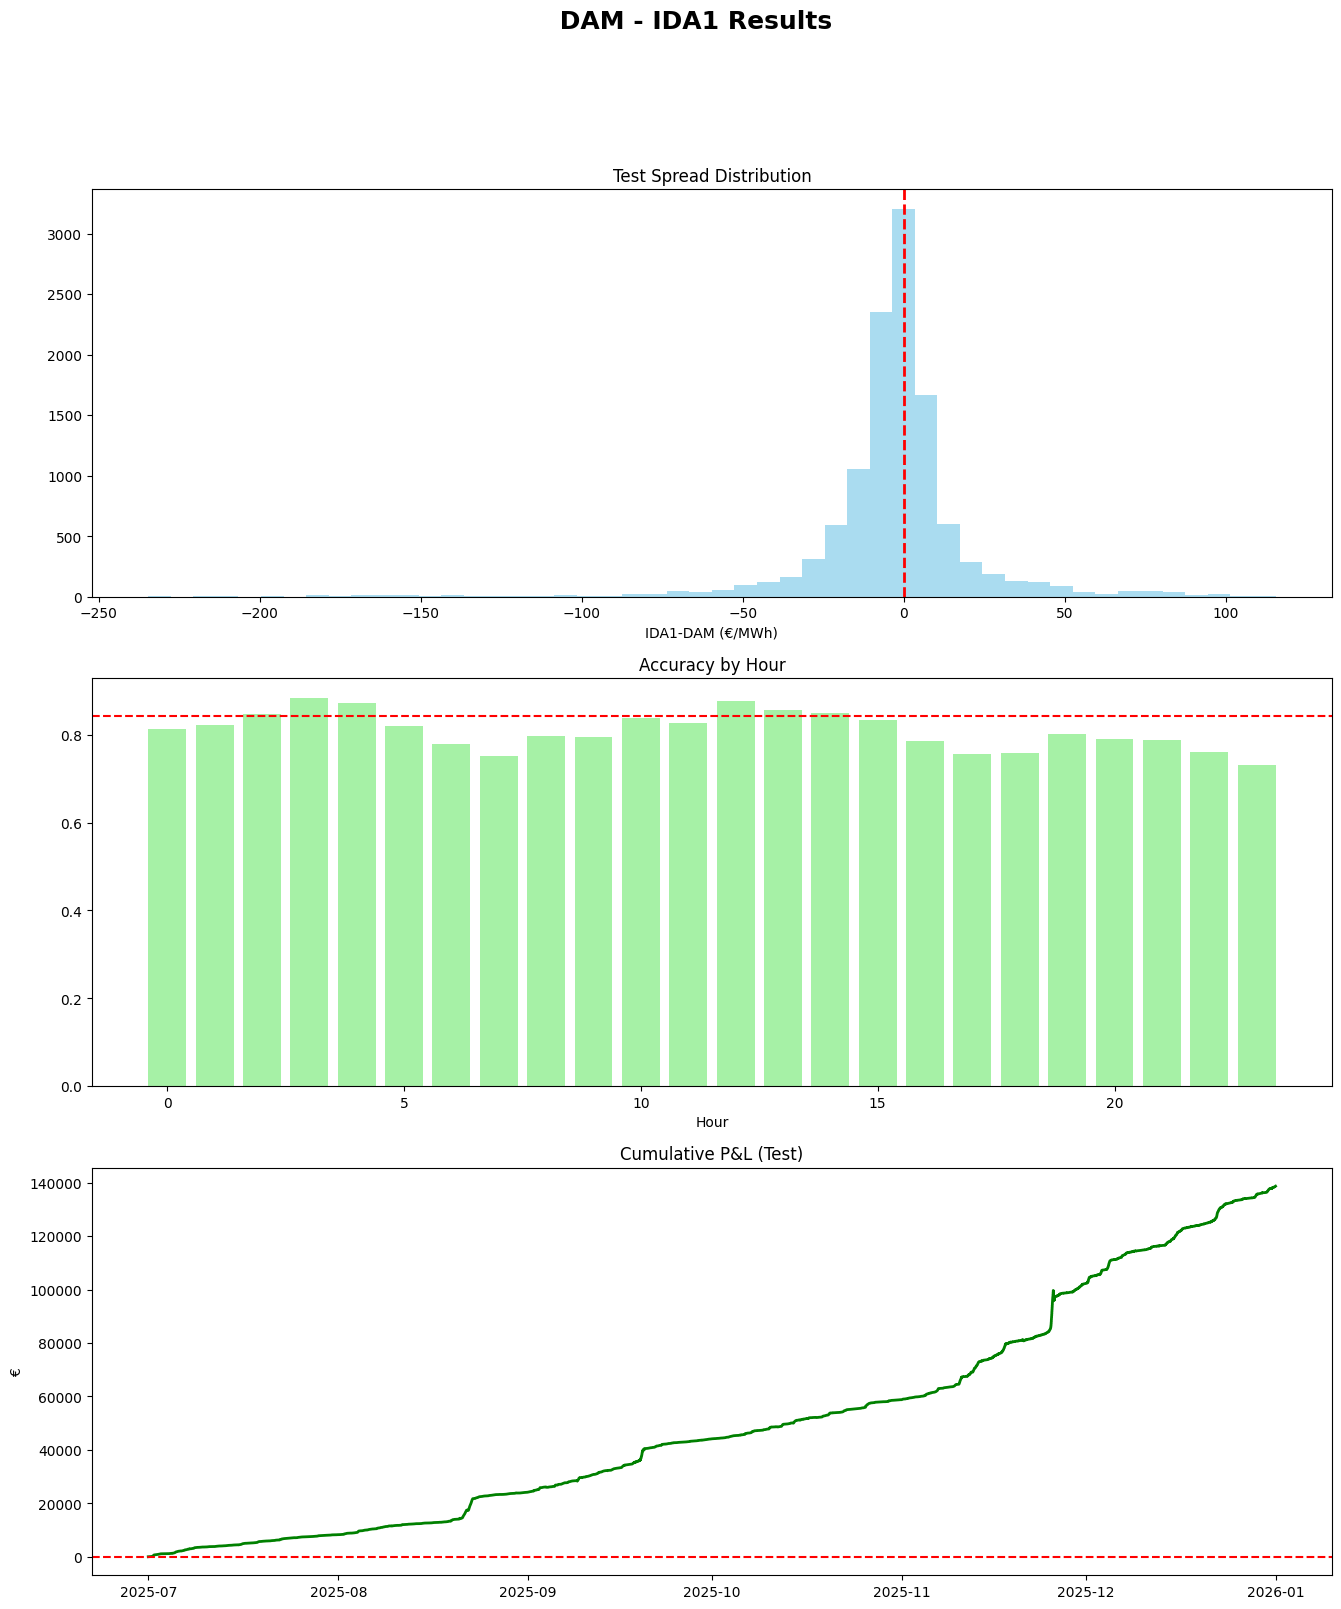

In [15]:

# 7. Main Method Execution
def main():    

    Energia_Market_Data = load_data(CFG.data_path)

    use_outages = False
    X_Market_Data, y_Market_Data, feature_cols = build_features(Energia_Market_Data, use_outages=use_outages)
    print(f" {len(X_Market_Data)} rows × {len(feature_cols)} features")
    
    #Splitting data using temporal split
    train_features, val_features, test_features, train_labels, val_labels, test_labels = temporal_split(Energia_Market_Data, X_Market_Data, y_Market_Data)
    print(f"   Train: {len(train_features):,} | Val: {len(val_features):,} | Test: {len(test_features):,}")
    print(train_features.head())
    model = build_histgb()
    model.fit(train_features, train_labels)

    #RandomForest (comparison baseline model)
    model_rf = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            min_samples_split=20,
            random_state=42,
            n_jobs=-1
        ))
    ])
    model_rf.fit(train_features, train_labels)

    print("\n Results:")
    
    # Validation data comparison
    val_labels_pred_h = model.predict(val_features)
    val_labels_pred_r = model_rf.predict(val_features)

    price_dam_val = Energia_Market_Data.loc[val_features.index, "PriceDAM"]
    price_ida1_val = Energia_Market_Data.loc[val_features.index, "PriceIDA1"]
    val_result_h = evaluate_strategy(val_labels, val_labels_pred_h, price_dam_val, price_ida1_val)
    val_result_r = evaluate_strategy(val_labels, val_labels_pred_r, price_dam_val, price_ida1_val)
    print(f"   Validation Summary HistGB: {val_result_h.accuracy:.1%} accuracy | €{val_result_h.pnl_per_mwh:.1f}/MWh")
    print(f"\nValidation Summary: RF {val_result_r.accuracy:.1%} accuracy | €{val_result_r.pnl_per_mwh:.1f}/MWh")

    #Test Data
    test_labels_pred_h = model.predict(test_features)
    test_labels_pred_p = model.predict_proba(test_features)
    mask = test_labels_pred_p > 0.6
    
    test_labels_pred_r = model_rf.predict(test_features)
    test_labels_pred_r_p = model_rf.predict_proba(test_features)[:, 1]

    print("PROBABILITY - ", len(test_labels_pred_p[mask]))
    price_dam_test = Energia_Market_Data.loc[test_features.index, "PriceDAM"]
    price_ida1_test = Energia_Market_Data.loc[test_features.index, "PriceIDA1"]
    test_result = evaluate_strategy(test_labels, test_labels_pred_h, price_dam_test, price_ida1_test)
    print(f"TEST:    {test_result.accuracy:.1%} accuracy | €{test_result.pnl_per_mwh:.1f}/MWh")
    print(f"             €{test_result.total_pnl:,.0f} total | {test_result.n_trades:,} trades")

    
    test_result_r = evaluate_strategy(test_labels, test_labels_pred_r, price_dam_test, price_ida1_test)
    print(f"RandomForest: {test_result_r.accuracy:.1%} accuracy | €{test_result_r.pnl_per_mwh:.1f}/MWh | €{test_result_r.total_pnl:,.0f}")
    print(f"\nTEST SUMMARY:")
    print(f"HistGB:    {test_result.accuracy:.1%} accuracy | €{test_result.pnl_per_mwh:.1f}/MWh | €{test_result.total_pnl:,.0f}")
    print(f"RandomForest: {test_result_r.accuracy:.1%} accuracy | €{test_result_r.pnl_per_mwh:.1f}/MWh | €{test_result_r.total_pnl:,.0f}")
    print(f"Gap:       +{test_result.accuracy-test_result_r.accuracy:.1%} accuracy proves HistGB's non-linearity!")
    
    
    out = Energia_Market_Data.loc[test_features.index, ["StartDateTime", "PriceDAM", "PriceIDA1"]].copy()
    out["y_true"] = test_labels.values
    out["y_pred"] = test_labels_pred_h
    out.to_csv("dam_ida1_predictions_test.csv", index=False)
    
    # Step 6: Publication plots
    print("6. Generating plots...")
    fig, axes = plt.subplots(3, figsize=(16, 18))
    fig.suptitle(' DAM - IDA1 Results', fontsize=18, fontweight='bold')
    
    # Plot 1: Spread distribution
    axes[0].hist(price_ida1_test - price_dam_test, bins=50, alpha=0.7, color='skyblue')
    axes[0].axvline(0, color='red', linestyle='--', lw=2)
    axes[0].set_title('Test Spread Distribution')
    axes[0].set_xlabel('IDA1-DAM (€/MWh)')
    
    # Plot 2: Hourly accuracy
    hourly_acc = []
    for h in range(24):
        mask = Energia_Market_Data.loc[test_features.index, "StartDateTime"].dt.hour == h
        if mask.sum() > 0:
            hourly_acc.append(accuracy_score(test_labels[mask], test_labels_pred_h[mask]))
        else:
            hourly_acc.append(0)
    axes[1].bar(range(24), hourly_acc, color='lightgreen', alpha=0.8)
    axes[1].axhline(test_result.accuracy, color='red', linestyle='--')
    axes[1].set_title('Accuracy by Hour')
    axes[1].set_xlabel('Hour')
    plt.savefig("accuracy_by_hour.png", dpi=300, bbox_inches="tight")
    
    # Plot 3: Cumulative P&L
    test_Energia_Market_Data = pd.DataFrame({
        'date': Energia_Market_Data.loc[test_features.index, "StartDateTime"],
        'pnl': test_labels_pred_h * (price_ida1_test - price_dam_test)
    })
    test_Energia_Market_Data['cum_pnl'] = test_Energia_Market_Data['pnl'].cumsum()
    axes[2].plot(test_Energia_Market_Data['date'], test_Energia_Market_Data['cum_pnl'], lw=2, color='green')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title('Cumulative P&L (Test)')
    axes[2].set_ylabel('€')
    plt.savefig("Cumulative P&L.png", dpi=300, bbox_inches="tight")


    
    print("Metric: €{:.1f}/MWh".format(test_result.pnl_per_mwh))

if __name__ == "__main__":
    main()
    